# Practical Statistics for Data Scientists
# AI-Assisted Statistics for Data Scientists
# Chapter 6: Statistical Machine Learning
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from collections import defaultdict
from itertools import product
from matplotlib.patches import Ellipse
from mlba import plotDecisionTree
from mlba import textDecisionTree
from sklearn import metrics
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Statistical Machine Learning
### K-Nearest Neighbors
#### A Small Example: Predicting Loan Default

In [1]:
loan200 = pd.read_csv(DATA_DIR / "loan200.csv")

predictors = ["payment_inc_ratio", "dti"]
outcome = "outcome"

newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
knn.predict(newloan)

array(['paid off'], dtype=object)

#### Standardization (Normalization, z-Scores)

In [1]:
loan_data = pd.read_csv(DATA_DIR / "loan_data.csv.gz")

predictors = ["payment_inc_ratio", "dti", "revol_bal", "revol_util"]
outcome = "outcome"

newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
X.iloc[nbrs[1][0], :]

,payment_inc_ratio,dti,revol_bal,revol_util
35536,1.47212,1.46,1686,10.0
33651,3.38178,6.37,1688,8.4
25863,2.36303,1.39,1691,3.5
42953,1.28160,7.14,1684,3.9
43599,4.12244,8.98,1684,7.2


In [1]:
newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

scaler = preprocessing.StandardScaler()
scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

nbrs = knn.kneighbors(newloan_std)
X.iloc[nbrs[1][0], :]

,payment_inc_ratio,dti,revol_bal,revol_util
2080,2.61091,1.03,1218,9.7
1438,2.34343,0.51,278,9.9
30215,2.71200,1.34,1075,8.5
28542,2.39760,0.74,2917,7.4
44737,2.34309,1.37,488,7.2


#### KNN as a Feature Engine

In [1]:
predictors = ["dti", "revol_bal", "revol_util", "open_acc",
              "delinq_2yrs_zero", "pub_rec_zero"]
outcome = "outcome"

X = loan_data[predictors]
y = loan_data[outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

loan_data["borrower_score"] = knn.predict_proba(X)[:, 1]
loan_data["borrower_score"].describe()

count    45342.000000
mean         0.498901
std          0.128735
min          0.050000
25%          0.400000
50%          0.500000
75%          0.600000
max          1.000000
Name: borrower_score, dtype: float64

### Tree Models
#### A Simple Example

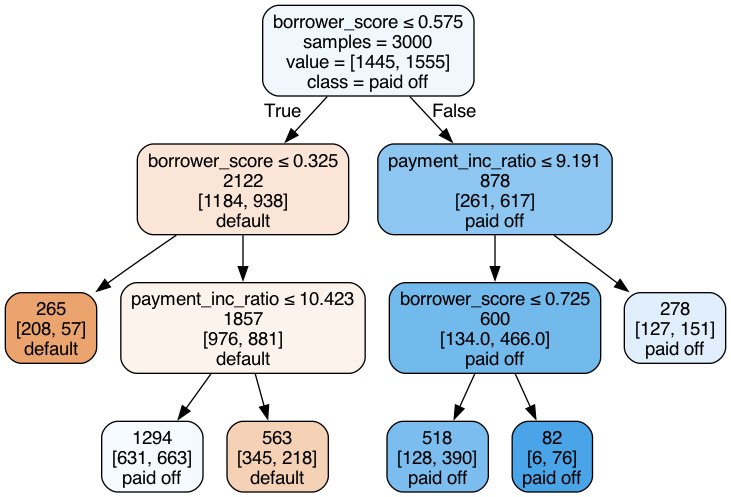

In [1]:
loan3000 = pd.read_csv(DATA_DIR / "loan3000.csv")

predictors = ["borrower_score", "payment_inc_ratio"]
outcome = "outcome"

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion="entropy",
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)
plotDecisionTree(loan_tree, feature_names=predictors,
                 class_names=loan_tree.classes_)

In [1]:
print(textDecisionTree(loan_tree))

node=0 test node: go to node 1 if 0 <= 0.5750000178813934 else to node 6
  node=1 test node: go to node 2 if 0 <= 0.32500000298023224 else to node 3
    node=2 leaf node: [[np.float64(0.785), np.float64(0.215)]]
    node=3 test node: go to node 4 if 1 <= 10.42264986038208 else to node 5
      node=4 leaf node: [[np.float64(0.488), np.float64(0.512)]]
      node=5 leaf node: [[np.float64(0.613), np.float64(0.387)]]
  node=6 test node: go to node 7 if 1 <= 9.19082498550415 else to node 10
    node=7 test node: go to node 8 if 0 <= 0.7249999940395355 else to node 9
      node=8 leaf node: [[np.float64(0.247), np.float64(0.753)]]
      node=9 leaf node: [[np.float64(0.073), np.float64(0.927)]]
    node=10 leaf node: [[np.float64(0.457), np.float64(0.543)]]


### Bagging and the Random Forest
#### Random Forest

In [1]:
predictors = ["borrower_score", "payment_inc_ratio"]
outcome = "outcome"

X = loan3000[predictors]
y = loan3000[outcome]

rf = RandomForestClassifier(n_estimators=500, random_state=1, oob_score=True,
                            n_jobs=4)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

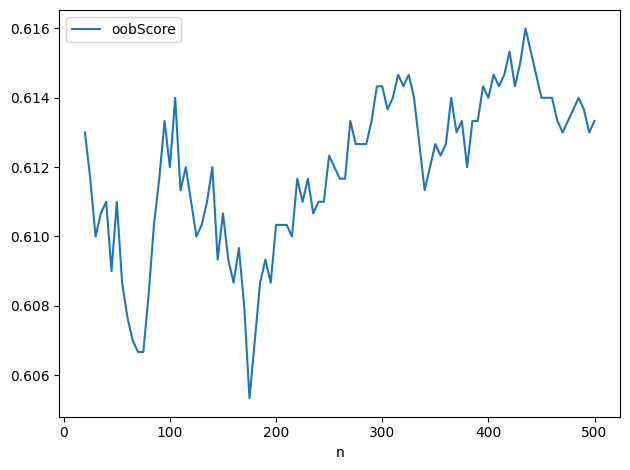

In [1]:
n_estimator = list(range(20, 505, 5))
oob_scores = []
for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n, criterion="entropy", n_jobs=4,
                                max_depth=5, random_state=1, oob_score=True)
    rf.fit(X, y)
    oob_scores.append(rf.oob_score_)
df = pd.DataFrame({"n": n_estimator, "oobScore": oob_scores})
df.plot(x="n", y="oobScore")

plt.tight_layout()
plt.show()

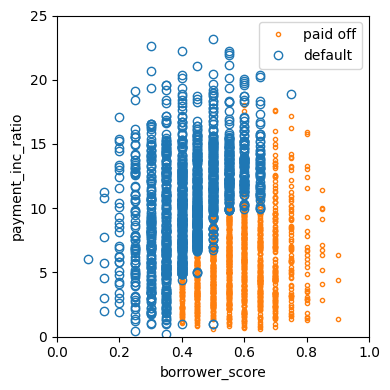

In [1]:
predictions = X.copy()
predictions["prediction"] = rf.predict(X)
predictions.head()

fig, ax = plt.subplots(figsize=(4, 4))

predictions.loc[predictions.prediction == "paid off"].plot(
    x="borrower_score", y="payment_inc_ratio", style=".",
    markerfacecolor="none", markeredgecolor="C1", ax=ax)
predictions.loc[predictions.prediction == "default"].plot(
    x="borrower_score", y="payment_inc_ratio", style="o",
    markerfacecolor="none", markeredgecolor="C0", ax=ax)
ax.legend(["paid off", "default"])
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")

plt.tight_layout()
plt.show()

#### Variable Importance

In [1]:
predictors = ["loan_amnt", "term", "annual_inc", "dti", "payment_inc_ratio",
              "revol_bal", "revol_util", "purpose", "delinq_2yrs_zero",
              "pub_rec_zero", "open_acc", "grade", "emp_length", "purpose_",
              "home_", "emp_len_", "borrower_score"]
outcome = "outcome"

X = pd.get_dummies(loan_data[predictors], drop_first=True)
y = loan_data[outcome]

rf_all = RandomForestClassifier(n_estimators=500, random_state=1, n_jobs=4)
rf_all.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [1]:
importances = rf_all.feature_importances_

In [1]:
rng = np.random.default_rng(seed=321)
rf = RandomForestClassifier(n_estimators=500, n_jobs=4)
scores = defaultdict(list)

# cross-validate the scores on a number of different random splits of the data
for _ in range(3):
    train_x, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.3)
    rf.fit(train_x, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = rng.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc - shuff_acc) / acc)

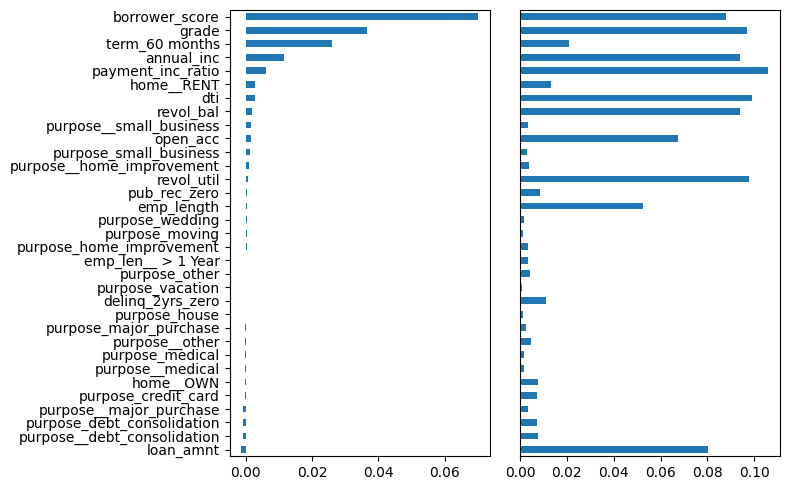

In [1]:
df = pd.DataFrame({
    "feature": X.columns,
    "Accuracy decrease": [np.mean(scores[column]) for column in X.columns],
    "Gini decrease": rf_all.feature_importances_,
})
df = df.sort_values("Accuracy decrease")

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = df.plot(kind="barh", x="feature", y="Accuracy decrease",
             legend=False, ax=axes[0])
ax.set_ylabel("")

ax = df.plot(kind="barh", x="feature", y="Gini decrease",
             legend=False, ax=axes[1])
ax.set_ylabel("")
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

### Boosting
#### XGBoost

In [1]:
predictors = ["borrower_score", "payment_inc_ratio"]
outcome = "outcome"

X = loan3000[predictors]
y = loan3000[outcome]
y = pd.Series([1 if o == "default" else 0 for o in loan3000[outcome]])

xgb = XGBClassifier(objective="binary:logistic", subsample=0.63)
xgb.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

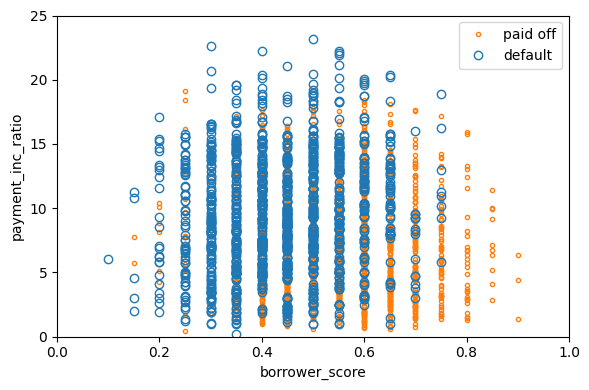

In [1]:
xgb_df = X.copy()
xgb_df["prediction"] = ["default" if p == 1 else "paid off"
    for p in xgb.predict(X)]
xgb_df["prob_default"] = xgb.predict_proba(X)[:, 0]

fig, ax = plt.subplots(figsize=(6, 4))

xgb_df.loc[xgb_df.prediction == "paid off"].plot(
    x="borrower_score", y="payment_inc_ratio", style=".",
    markerfacecolor="none", markeredgecolor="C1", ax=ax)
xgb_df.loc[xgb_df.prediction == "default"].plot(
    x="borrower_score", y="payment_inc_ratio", style="o",
    markerfacecolor="none", markeredgecolor="C0", ax=ax)
ax.legend(["paid off", "default"])
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")

plt.tight_layout()
plt.show()

#### Regularization: Avoiding Overfitting

In [1]:
predictors = ["loan_amnt", "term", "annual_inc", "dti", "payment_inc_ratio",
              "revol_bal", "revol_util", "purpose", "delinq_2yrs_zero",
              "pub_rec_zero", "open_acc", "grade", "emp_length", "purpose_",
              "home_", "emp_len_", "borrower_score"]
outcome = "outcome"

X = pd.get_dummies(loan_data[predictors], drop_first=True)
y = pd.Series([1 if o == "default" else 0 for o in loan_data[outcome]])

train_x, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000)

xgb_default = XGBClassifier(objective="binary:logistic", n_estimators=250,
                            max_depth=6, reg_lambda=0, learning_rate=0.3,
                            subsample=1)
xgb_default.fit(train_x, train_y)

pred_default = xgb_default.predict_proba(valid_X)[:, 1]
error_default = abs(valid_y - pred_default) > 0.5
print("default: ", np.mean(error_default))

default:  0.364


In [1]:
xgb_penalty = XGBClassifier(objective="binary:logistic", n_estimators=250,
                            max_depth=6, reg_lambda=1000, learning_rate=0.1,
                            subsample=0.63)
xgb_penalty.fit(train_x, train_y)
pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
error_penalty = abs(valid_y - pred_penalty) > 0.5
print("penalty: ", np.mean(error_penalty))

penalty:  0.3274


In [1]:
results = []
for ntree_limit in range(1, 250):
    iteration_range = [1, ntree_limit + 1]
    train_default = xgb_default.predict_proba(train_x,
        iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_x,
        iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X,
        iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X,
        iteration_range=iteration_range)[:, 1]
    results.append({
        "iterations": ntree_limit,
        "default train": np.mean(abs(train_y - train_default) > 0.5),
        "penalty train": np.mean(abs(train_y - train_penalty) > 0.5),
        "default test": np.mean(abs(valid_y - pred_default) > 0.5),
        "penalty test": np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
results.head()

,iterations,default train,penalty train,default test,penalty test
0,1,0.345962,0.350490,0.3573,0.3531
1,2,0.331306,0.343755,0.3477,0.3479
2,3,0.325081,0.341124,0.3431,0.3415
3,4,0.320836,0.342199,0.3395,0.3404
4,5,0.318686,0.342058,0.3424,0.3396


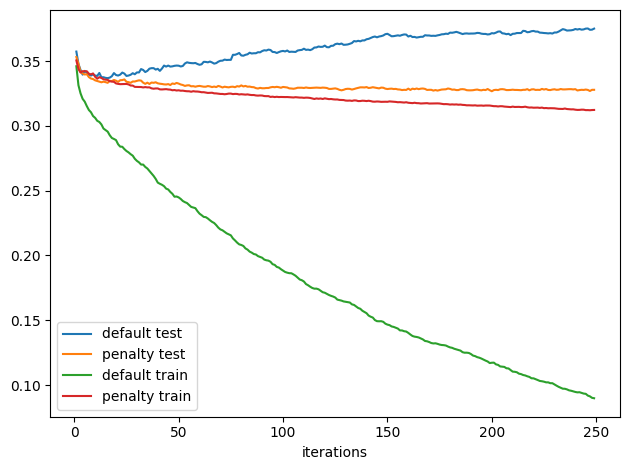

In [1]:
ax = results.plot(x="iterations", y="default test")
results.plot(x="iterations", y="penalty test", ax=ax)
results.plot(x="iterations", y="default train", ax=ax)
results.plot(x="iterations", y="penalty train", ax=ax)

plt.tight_layout()
plt.show()

#### Hyperparameters and Cross-Validation

In [1]:
rng = np.random.default_rng(seed=321)
idx = rng.choice(range(5), size=len(X), replace=True)
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective="binary:logistic", n_estimators=250,
                        max_depth=max_depth, learning_rate=eta)
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        train_x = X.loc[~fold_idx]; train_y = y[~fold_idx]
        valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]

        xgb.fit(train_x, train_y)
        pred = xgb.predict_proba(valid_X)[:, 1]
        cv_error.append(np.mean(abs(valid_y - pred) > 0.5))
    error.append({
        "eta": eta,
        "max_depth": max_depth,
        "avg_error": np.mean(cv_error),
    })
    print(error[-1])
errors = pd.DataFrame(error)

table = errors.pivot_table(index="eta", columns="max_depth", values="avg_error")
print(table * 100)

{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.32901685739015657)}


{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.33584569147367743)}


{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.3465400449213362)}


{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.3382451177824208)}


{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.3693638861385647)}


{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.3704949129861085)}


{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.34945523328002775)}


{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.38570299596812696)}


{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.3824637201456234)}
max_depth          3          6          9
eta                                       
0.1        32.901686  33.584569  34.654004
0.5        33.824512  36.936389  37.049491
0.9        34.945523  38.570300  38.246372


# Supplementary Material
## Figure 6-2. KNN prediction of loan default using two variables: debt-to-income ratio and loan-payment-to-income ratio

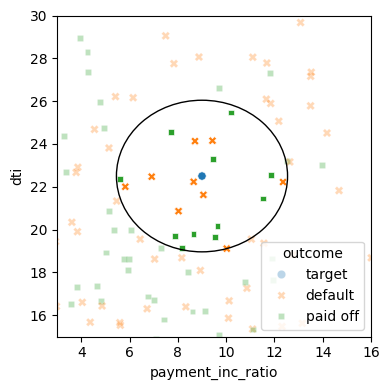

In [1]:
predictors = ["payment_inc_ratio", "dti"]
outcome = "outcome"
newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x="payment_inc_ratio", y="dti", style="outcome",
                hue="outcome", data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x="payment_inc_ratio", y="dti", style="outcome",
                hue="outcome",
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1, :]]),
                ax=ax, legend=False)
ellipse = Ellipse(xy=newloan.to_numpy()[0],
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor="black", fc="None", lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16)
ax.set_ylim(15, 30)

plt.tight_layout()
plt.show()

## Figure 6-4. The first five rules for a simple tree model fit to the loan data

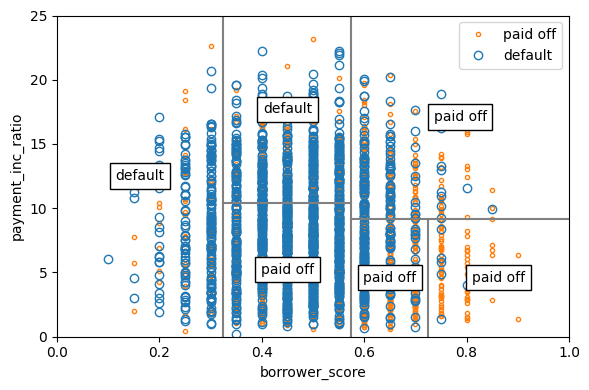

In [1]:
fig, ax = plt.subplots(figsize=(6, 4))

loan3000.loc[loan3000.outcome == "paid off"].plot(
    x="borrower_score", y="payment_inc_ratio", style=".",
    markerfacecolor="none", markeredgecolor="C1", ax=ax)
loan3000.loc[loan3000.outcome == "default"].plot(
    x="borrower_score", y="payment_inc_ratio", style="o",
    markerfacecolor="none", markeredgecolor="C0", ax=ax)
ax.legend(["paid off", "default"])
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")

x0 = 0.575
x1a = 0.325; y1b = 9.191
y2a = 10.423; x2b = 0.725
ax.plot((x0, x0), (0, 25), color="grey")
ax.plot((x1a, x1a), (0, 25), color="grey")
ax.plot((x0, 1), (y1b, y1b), color="grey")
ax.plot((x1a, x0), (y2a, y2a), color="grey")
ax.plot((x2b, x2b), (0, y1b), color="grey")

labels = [("default", (x1a / 2, 25 / 2)),
          ("default", ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ("paid off", ((x0 + x1a) / 2, y2a / 2)),
          ("paid off", ((1 + x0) / 2, (y1b + 25) / 2)),
          ("paid off", ((1 + x2b) / 2, (y1b + 0) / 2)),
          ("paid off", ((x0 + x2b) / 2, (y1b + 0) / 2)),
         ]
for label, (x, y) in labels:
    ax.text(x, y, label, bbox={"facecolor": "white"},
            verticalalignment="center", horizontalalignment="center")

plt.tight_layout()
plt.show()

## Figure 6-5. Gini impurity and entropy measures

In [1]:
def entropy_function(x):
    if x == 0:
        return 0
    return -x * math.log2(x) - (1 - x) * math.log2(1 - x)

def gini_function(x):
    return x * (1 - x)

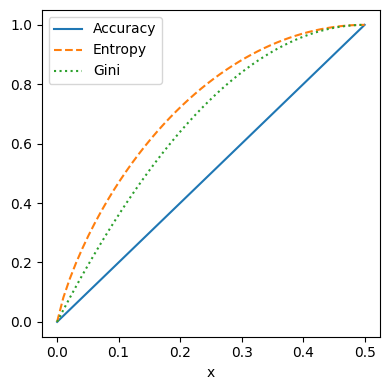

In [1]:
x = np.linspace(0, 0.5, 50)
impure = pd.DataFrame({
    "x": x,
    "Accuracy": 2 * x,
    "Gini": [gini_function(xi) / gini_function(0.5) for xi in x],
    "Entropy": [entropy_function(xi) for xi in x],
})

fig, ax = plt.subplots(figsize=(4, 4))

impure.plot(x="x", y="Accuracy", ax=ax, linestyle="solid")
impure.plot(x="x", y="Entropy", ax=ax, linestyle="--")
impure.plot(x="x", y="Gini", ax=ax, linestyle=":")

plt.tight_layout()
plt.show()